In [ ]:
import pandas as pd
import numpy as np
import re
import string
import pickle
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

# 1. Setup NLTK Preprocessing
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def advanced_cleaning(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<%s>+' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

# 2. Load and Prepare Data (WELFake_Dataset)
print("Step 1: Loading WELFake Data...")
df = pd.read_csv('/content/WELFake_Dataset.csv')
df = df.dropna(subset=['title', 'text', 'label'])
df['total_content'] = df['title'] + " " + df['text']

print("Step 2: Cleaning Text...")
df['total_content'] = df['total_content'].apply(advanced_cleaning)

# 3. Feature Extraction (TF-IDF)
print("Step 3: Vectorizing...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['total_content']).toarray()
y = df['label'].astype(int).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Building the ANN Model
print("Step 4: Building the Neural Network...")
model = Sequential([
    Input(shape=(5000,)),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Training
print("Step 5: Training...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2, callbacks=[early_stop])

# 6. Saving Artifacts
print("\nStep 6: Saving Artifacts...")
model.save('tf_model_welfake.keras')
with open('tfidf_vectorizer_welfake.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# 7. Verification
print("Step 7: Evaluation Report...")
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Step 1: Loading WELFake Data...
Step 2: Cleaning Text...
Step 3: Vectorizing...
Step 4: Building the Neural Network...
Step 5: Training...
Epoch 1/10
716/716 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9250 - loss: 0.1910 - val_accuracy: 0.9555 - val_loss: 0.1174
Epoch 2/10
716/716 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9640 - loss: 0.0945 - val_accuracy: 0.9592 - val_loss: 0.1119
Epoch 3/10
716/716 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9783 - loss: 0.0581 - val_accuracy: 0.9635 - val_loss: 0.1150
Epoch 4/10
716/716 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9853 - loss: 0.0397 - val_accuracy: 0.9611 - val_loss: 0.1290
Epoch 5/10
716/716 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9885 - loss: 0.0306 - val_accuracy: 0.9656 - val_loss: 0.1276

Step 6: Saving Artifacts...
Step 7: Evaluation Report...
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7081
           

### Fully Standalone PyTorch Pipeline
This section re-implements everything from data loading to model saving to ensure the workflow is self-contained.

In [ ]:
import pandas as pd
import re
import string
import pickle
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- 1. Preprocessing Setup ---
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text_scratch(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

# --- 2. Data Loading & Cleaning (WELFake_Dataset) ---
print("Loading and cleaning WELFake_Dataset.csv...")
# WELFake has columns: title, text, label
data = pd.read_csv('/content/WELFake_Dataset.csv')

# Handle missing values which are common in this dataset
data = data.dropna(subset=['title', 'text'])

data['content'] = (data['title'] + " " + data['text']).apply(clean_text_scratch)
y_labels = data['label'].values

# --- 3. Feature Extraction ---
print("Vectorizing features...")
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_processed = vectorizer.fit_transform(data['content']).toarray()

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_processed, y_labels, test_size=0.2, random_state=42)

# --- 4. PyTorch Dataset & Model ---
train_ds = TensorDataset(torch.tensor(X_train_s, dtype=torch.float32), torch.tensor(y_train_s, dtype=torch.float32).view(-1,1))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

class FakeNewsTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5000, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_torch = FakeNewsTorch().to(device)
opt = optim.Adam(model_torch.parameters(), lr=0.001)
crit = nn.BCELoss()

# --- 5. Training Loop ---
print(f"Training on {device}...")
for e in range(5):
    model_torch.train()
    curr_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model_torch(xb), yb)
        loss.backward()
        opt.step()
        curr_loss += loss.item()
    print(f"Epoch {e+1}/5 | Loss: {curr_loss/len(train_dl):.4f}")

# --- 6. Save ---
torch.save(model_torch.state_dict(), 'pytorch_model_welfake.pth')
with open('vectorizer_welfake.pkl', 'wb') as f: pickle.dump(vectorizer, f)
print("PyTorch artifacts for WELFake saved successfully.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading and cleaning WELFake_Dataset.csv...
Vectorizing features...
Training on cuda...
Epoch 1/5 | Loss: 0.1643
Epoch 2/5 | Loss: 0.0868
Epoch 3/5 | Loss: 0.0553
Epoch 4/5 | Loss: 0.0413
Epoch 5/5 | Loss: 0.0300
PyTorch artifacts for WELFake saved successfully.


Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.96      0.97      7081
        Real       0.96      0.97      0.97      7227

    accuracy                           0.97     14308
   macro avg       0.97      0.97      0.97     14308
weighted avg       0.97      0.97      0.97     14308



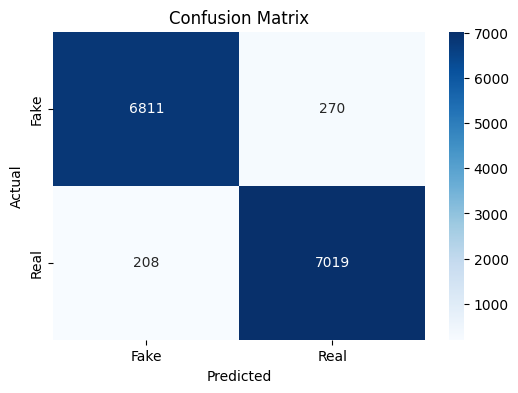

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

model_torch.eval()
with torch.no_grad():
    # Convert predictions to a numpy array for sklearn metrics
    y_pred_probs = model_torch(torch.tensor(X_test_s, dtype=torch.float32).to(device)).cpu().numpy()
    y_pred = (y_pred_probs > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test_s, y_pred, target_names=['Fake', 'Real']))

# Visualize Confusion Matrix
cm = confusion_matrix(y_test_s, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 3. Model Comparison and Selection
We will evaluate both models on the test set and save the one with the highest accuracy for the web application.